# Chicago Crash Severity - Descriptive Analysis and EDA

This notebook is the analysis evidence for the final project.

**Business problem:** predict whether a crash is severe (fatal or incapacitating injury) so safety teams can prioritize prevention actions.

## 1) Setup and Imports

Run this notebook after at least one ingestion pass.

Recommended order:
1. `python src/app.py --mode ingest --start-date 2021-01-01`
2. `python src/app.py --mode prepare --start-date 2021-01-01`

In [17]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)


In [18]:
from pipeline_config import PROJECT_ROOT, RAW_DATA_DIR, PROCESSED_DATA_DIR
from utils import db_connect

print('Project root:', PROJECT_ROOT)
print('Raw data dir:', RAW_DATA_DIR)
print('Processed data dir:', PROCESSED_DATA_DIR)

Project root: D:\Bootcamp_Data_Science_Final_Project\Machine-Learning-Final-Project
Raw data dir: D:\Bootcamp_Data_Science_Final_Project\Machine-Learning-Final-Project\data\raw
Processed data dir: D:\Bootcamp_Data_Science_Final_Project\Machine-Learning-Final-Project\data\processed


## 2) Load Data (DB first, CSV fallback)

In [19]:
def load_crash_features() -> pd.DataFrame:
    """Load curated modeling table from DB; fallback to processed CSV if DB is unavailable."""
    try:
        engine = db_connect()
        query = text('SELECT * FROM crash_features')
        df = pd.read_sql(query, engine)
        if not df.empty:
            print(f'Loaded from DB: {df.shape}')
            return df
    except Exception as exc:
        print('DB load skipped:', exc)

    csv_path = PROCESSED_DATA_DIR / 'crash_features.csv'
    if not csv_path.exists():
        raise FileNotFoundError(
            'No `crash_features` source found. Run prepare mode first: '
            '`python src/app.py --mode prepare --start-date 2021-01-01`'
        )

    df = pd.read_csv(csv_path, low_memory=False)
    print(f'Loaded from CSV: {df.shape}')
    return df

df = load_crash_features().copy()
df.head()

Loaded from DB: (573521, 28)


,crash_record_id,crash_date,posted_speed_limit,traffic_control_device,intersection_related_i,hit_and_run_i,work_zone_i,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,prim_contributory_cause,sec_contributory_cause,crash_hour,crash_day_of_week,crash_month,num_units,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_total,vehicle_count,towed_vehicle_count,people_count,driver_count
0,7438d0a2cd7729c86a154250988b2a1ebdb4fd6a04ec33...,2021-01-29 18:50:00,20.0,NO CONTROLS,None,Y,None,CLEAR,"DARKNESS, LIGHTED ROAD",PEDESTRIAN,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,WET,NO DEFECTS,UNABLE TO DETERMINE,UNABLE TO DETERMINE,18.0,6.0,1.0,2.0,0.0,0.0,1.0,1.0,2.0,0.0,2.0,1.0
1,645df56501f46d98ee16927822dd9f4f2d8c20ee93d1c6...,2021-02-11 20:31:00,30.0,NO CONTROLS,None,Y,None,CLEAR,"DARKNESS, LIGHTED ROAD",REAR END,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,WET,NO DEFECTS,UNABLE TO DETERMINE,NOT APPLICABLE,20.0,5.0,2.0,2.0,0.0,0.0,1.0,1.0,2.0,0.0,2.0,2.0
2,37e863cc38e8c86875fa8aa6872abef321ca6284a6daad...,2021-01-07 17:42:00,30.0,TRAFFIC SIGNAL,None,None,None,CLEAR,"DARKNESS, LIGHTED ROAD",REAR END,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,FOLLOWING TOO CLOSELY,NOT APPLICABLE,17.0,5.0,1.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0
3,08c558fbeff8403da0c7eb91c91e388164c286b655f7bd...,2021-03-13 14:05:00,30.0,NO CONTROLS,None,None,None,CLEAR,DAYLIGHT,PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,UNABLE TO DETERMINE,14.0,7.0,3.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0
4,88695ad60b040e5ed40f0c574e25d30973f3065388bf5a...,2021-03-01 16:54:00,35.0,TRAFFIC SIGNAL,Y,None,None,CLEAR,DAWN,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,IMPROPER OVERTAKING/PASSING,UNABLE TO DETERMINE,16.0,2.0,3.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0


## 3) SQL Evidence (SELECT / JOIN / INSERT Artifacts)

This section documents the SQL-backed stage required in the rubric.

In [20]:
sql_file = PROJECT_ROOT / 'sql' / 'crash_feature_queries.sql'
print('SQL artifact exists:', sql_file.exists())
if sql_file.exists():
    print(sql_file)

SQL artifact exists: True
D:\Bootcamp_Data_Science_Final_Project\Machine-Learning-Final-Project\sql\crash_feature_queries.sql


In [21]:
# Optional DB check: raw table sizes + curated size
try:
    engine = db_connect()
    q = text(
        """
        SELECT
            (SELECT COUNT(*) FROM crashes_raw) AS crashes_rows,
            (SELECT COUNT(*) FROM vehicles_raw) AS vehicles_rows,
            (SELECT COUNT(*) FROM people_raw) AS people_rows,
            (SELECT COUNT(*) FROM crash_features) AS feature_rows
        """
    )
    display(pd.read_sql(q, engine))
except Exception as exc:
    print('DB query skipped:', exc)

,crashes_rows,vehicles_rows,people_rows,feature_rows
0,573521,1170253,1251171,573521


## 4) Target Engineering and Data Preparation

In [22]:
df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')
df = df.dropna(subset=['crash_date']).copy()

for col in ['injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_total']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['severe'] = ((df['injuries_fatal'] > 0) | (df['injuries_incapacitating'] > 0)).astype(int)
df = df.sort_values('crash_date').reset_index(drop=True)

print('Data shape:', df.shape)
print('Severe rate:', round(df['severe'].mean(), 4))
df[['crash_date', 'injuries_fatal', 'injuries_incapacitating', 'severe']].head()

Data shape: (573521, 29)
Severe rate: 0.0172


,crash_date,injuries_fatal,injuries_incapacitating,severe
0,2021-01-01 00:00:00,0.0,0.0,0
1,2021-01-01 00:04:00,0.0,0.0,0
2,2021-01-01 00:05:00,0.0,0.0,0
3,2021-01-01 00:05:00,0.0,0.0,0
4,2021-01-01 00:10:00,0.0,0.0,0


## 5) Descriptive Statistics

In [23]:
numeric_cols = [
    'posted_speed_limit', 'crash_hour', 'crash_day_of_week', 'crash_month',
    'num_units', 'vehicle_count', 'towed_vehicle_count', 'people_count', 'driver_count',
    'injuries_total'
]
numeric_cols = [c for c in numeric_cols if c in df.columns]
desc = df[numeric_cols].describe().T
desc

,count,mean,std,min,25%,50%,75%,max
posted_speed_limit,573521.0,28.522896,5.618913,0.0,30.0,30.0,30.0,70.0
crash_hour,573521.0,13.152286,5.634860,0.0,9.0,14.0,17.0,23.0
crash_day_of_week,573521.0,4.111128,1.981959,1.0,2.0,4.0,6.0,7.0
crash_month,573521.0,6.426051,3.420857,1.0,3.0,6.0,9.0,12.0
num_units,573521.0,2.037160,0.456727,1.0,2.0,2.0,2.0,18.0
vehicle_count,573521.0,2.040471,0.467398,1.0,2.0,2.0,2.0,18.0
towed_vehicle_count,573521.0,0.259138,0.559149,0.0,0.0,0.0,0.0,7.0
people_count,573521.0,2.181561,1.176656,0.0,2.0,2.0,2.0,54.0
driver_count,573521.0,1.701814,0.557102,0.0,1.0,2.0,2.0,12.0
injuries_total,573521.0,0.215710,0.600762,0.0,0.0,0.0,0.0,21.0


In [24]:
missing_df = (df.isna().mean() * 100).sort_values(ascending=False).rename('missing_pct').to_frame()
missing_df.head(20)

,missing_pct
work_zone_i,99.559388
intersection_related_i,76.640611
hit_and_run_i,66.823534
crash_record_id,0.000000
crash_date,0.000000
traffic_control_device,0.000000
posted_speed_limit,0.000000
weather_condition,0.000000
lighting_condition,0.000000
first_crash_type,0.000000


## 6) Full EDA

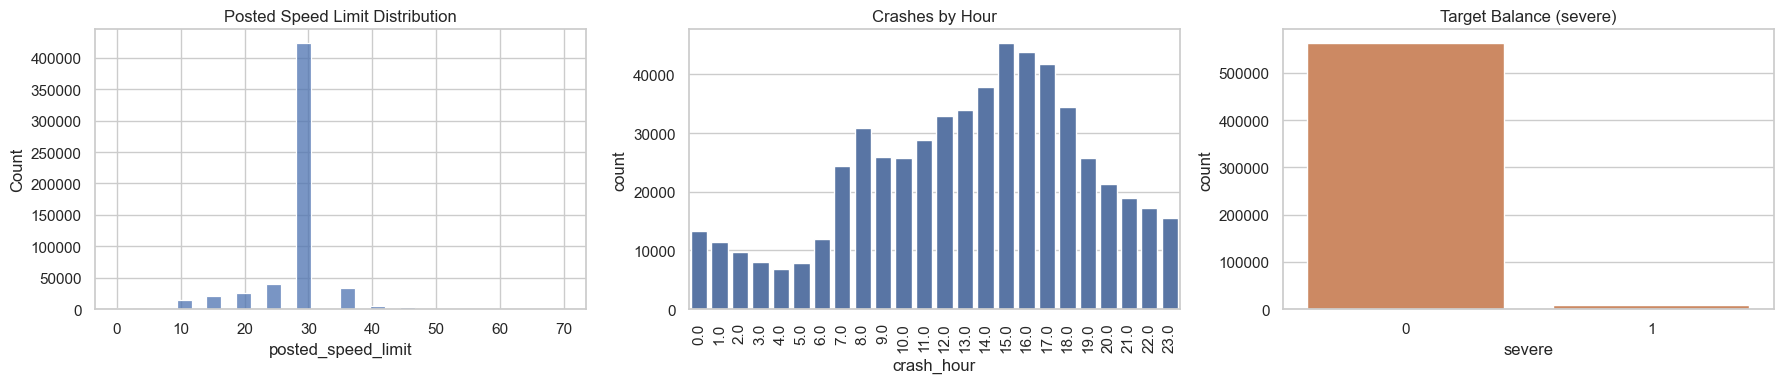

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df['posted_speed_limit'], bins=30, ax=axes[0], kde=False)
axes[0].set_title('Posted Speed Limit Distribution')

sns.countplot(data=df, x='crash_hour', ax=axes[1], color='#4c72b0')
axes[1].set_title('Crashes by Hour')
axes[1].tick_params(axis='x', rotation=90)

sns.countplot(data=df, x='severe', ax=axes[2], color='#dd8452')
axes[2].set_title('Target Balance (severe)')

plt.tight_layout()
plt.show()

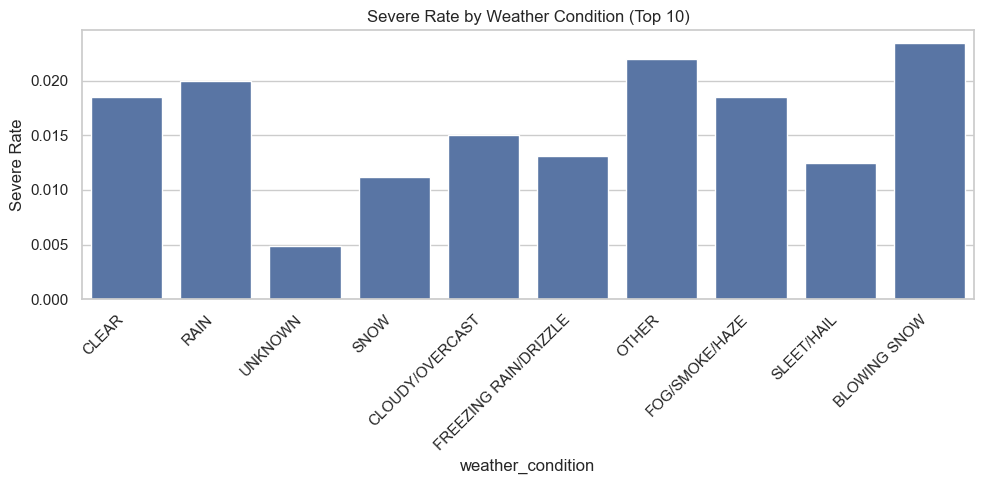

In [26]:
top_weather = df['weather_condition'].fillna('UNKNOWN').value_counts().head(10).index
weather_plot = df[df['weather_condition'].fillna('UNKNOWN').isin(top_weather)].copy()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=weather_plot,
    x='weather_condition',
    y='severe',
    estimator=np.mean,
    errorbar=None,
    order=top_weather
)
plt.title('Severe Rate by Weather Condition (Top 10)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Severe Rate')
plt.tight_layout()
plt.show()

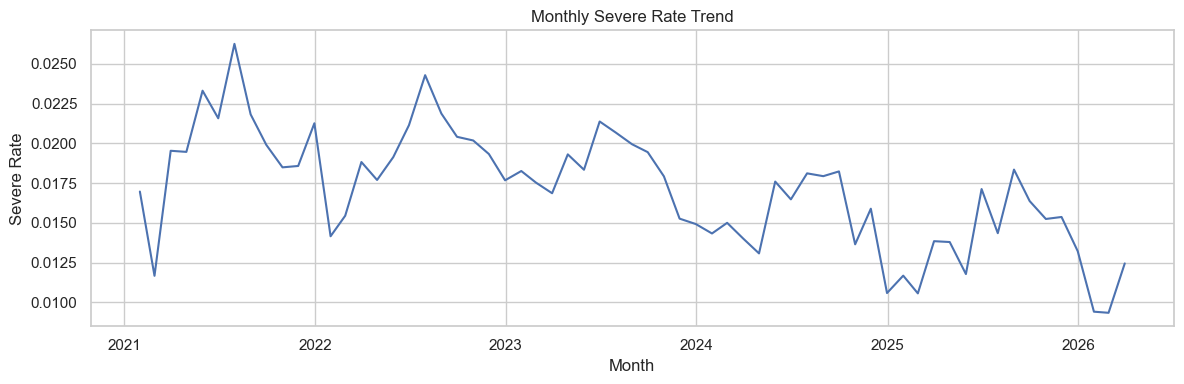

In [27]:
daily = df.set_index('crash_date').resample('M')['severe'].mean().rename('monthly_severe_rate').reset_index()

plt.figure(figsize=(12, 4))
sns.lineplot(data=daily, x='crash_date', y='monthly_severe_rate')
plt.title('Monthly Severe Rate Trend')
plt.xlabel('Month')
plt.ylabel('Severe Rate')
plt.tight_layout()
plt.show()

## 7) Hypothesis Test Example (Optional in Rubric)

In [28]:
cat_feature = 'lighting_condition'
sample_df = df[[cat_feature, 'severe']].dropna().copy()
top_levels = sample_df[cat_feature].value_counts().head(8).index
sample_df = sample_df[sample_df[cat_feature].isin(top_levels)]

cont = pd.crosstab(sample_df[cat_feature], sample_df['severe'])
chi2, p_value, dof, expected = chi2_contingency(cont)

print('Chi-square statistic:', round(chi2, 4))
print('p-value:', p_value)
print('dof:', dof)
print('Interpretation: reject H0 if p-value < 0.05')

Chi-square statistic: 1139.1958
p-value: 4.341527587045757e-244
dof: 5
Interpretation: reject H0 if p-value < 0.05


## 8) Feature Selection and Leakage Controls

In [29]:
numeric_features = [
    'posted_speed_limit', 'crash_hour', 'crash_day_of_week', 'crash_month',
    'num_units', 'vehicle_count', 'towed_vehicle_count', 'people_count', 'driver_count'
]
categorical_features = [
    'traffic_control_device', 'intersection_related_i', 'hit_and_run_i', 'work_zone_i',
    'weather_condition', 'lighting_condition',
    'first_crash_type', 'trafficway_type', 'alignment', 'roadway_surface_cond',
    'road_defect', 'prim_contributory_cause', 'sec_contributory_cause'
]
leakage_columns = [
    'injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_total'
]

selected_features = [c for c in (numeric_features + categorical_features) if c in df.columns]
print('Selected features:', len(selected_features))
print('Categorical:', len([c for c in categorical_features if c in df.columns]))
print('Leakage columns excluded from X:', [c for c in leakage_columns if c in df.columns])

Selected features: 22
Categorical: 13
Leakage columns excluded from X: ['injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_total']


## 9) Time-Aware Train/Validation/Test Split

In [30]:
model_df = df[['crash_date', 'severe'] + selected_features].dropna(subset=['severe']).copy()
model_df = model_df.sort_values('crash_date').reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.8)
valid_end = int(n * 0.9)

train_df = model_df.iloc[:train_end]
valid_df = model_df.iloc[train_end:valid_end]
test_df = model_df.iloc[valid_end:]

print('Train shape:', train_df.shape)
print('Validation shape:', valid_df.shape)
print('Test shape:', test_df.shape)
print('Date ranges:')
print('  Train:', train_df['crash_date'].min(), '->', train_df['crash_date'].max())
print('  Valid:', valid_df['crash_date'].min(), '->', valid_df['crash_date'].max())
print('  Test :', test_df['crash_date'].min(), '->', test_df['crash_date'].max())

Train shape: (458816, 24)
Validation shape: (57352, 24)
Test shape: (57353, 24)
Date ranges:
  Train: 2021-01-01 00:00:00 -> 2025-03-11 10:00:00
  Valid: 2025-03-11 10:00:00 -> 2025-09-08 16:09:00
  Test : 2025-09-08 16:09:00 -> 2026-03-27 00:38:00
